# **Data Preprocessing Extracting and Combining Information**

## **Extracting Information from stdID**

In [54]:
import numpy as np
import pandas as pd

df = pd.read_csv(r"D:\Codes\MachineLearning\Datasets\extracting-data.csv")
df

,id,cgpa,scholarship
0,BDSF22M512,3.69,yes
1,BSEF19M025,2.50,no
2,BCSF19A541,3.80,yes
3,BDSF22M511,2.60,no
4,BITF21A012,3.00,no
5,BSEF21M521,3.10,no
6,BSEF22M028,3.75,yes
7,BDSF22A519,3.79,yes
8,BSEF20M020,3.25,no
9,BDSF22M521,3.90,yes


In [55]:
df['id']

0     BDSF22M512
1     BSEF19M025
2     BCSF19A541
3     BDSF22M511
4     BITF21A012
5     BSEF21M521
6     BSEF22M028
7     BDSF22A519
8     BSEF20M020
9     BDSF22M521
10    BITF19M026
11    BSEF20M012
12    BDSF22M507
13    BDSF22A525
14    BCSF21A014
15    BCSF19M527
Name: id, dtype: object

In [56]:
df['degree'] = df['id'].str[0:3:1]
df['batch'] = df['id'].str[3:6:1]
df['session'] = df['id'].str[6:7:1]
df['rollno'] = df['id'].str[7::1].astype(np.uint16)
df['campus'] = np.where(df['rollno']>500, 'new-campus', 'old-campus')
df

,id,cgpa,scholarship,degree,batch,session,rollno,campus
0,BDSF22M512,3.69,yes,BDS,F22,M,512,new-campus
1,BSEF19M025,2.50,no,BSE,F19,M,25,old-campus
2,BCSF19A541,3.80,yes,BCS,F19,A,541,new-campus
3,BDSF22M511,2.60,no,BDS,F22,M,511,new-campus
4,BITF21A012,3.00,no,BIT,F21,A,12,old-campus
5,BSEF21M521,3.10,no,BSE,F21,M,521,new-campus
6,BSEF22M028,3.75,yes,BSE,F22,M,28,old-campus
7,BDSF22A519,3.79,yes,BDS,F22,A,519,new-campus
8,BSEF20M020,3.25,no,BSE,F20,M,20,old-campus
9,BDSF22M521,3.90,yes,BDS,F22,M,521,new-campus


## **Extracting info from date feature**

In [57]:
import datetime as dt
import time
df = pd.read_csv(r"D:\Codes\MachineLearning\Datasets\cryptodata.csv")
df.head(5)

,Date,Symbol,Open,High,Low,Close,Volume
0,2020-03-13 08-PM,ETHUSD,129.94,131.82,126.87,128.71,1940673.93
1,2020-03-13 07-PM,ETHUSD,119.51,132.02,117.10,129.94,7579741.09
2,a,ETHUSD,124.47,124.85,115.50,119.51,4898735.81
3,2020-03-13 05-PM,ETHUSD,124.08,127.42,121.63,124.47,2753450.92
4,2020-03-13 04-PM,ETHUSD,124.85,129.51,120.17,124.08,4461424.71


In [58]:
print(dir(time))

['_STRUCT_TM_ITEMS', '__doc__', '__loader__', '__name__', '__package__', '__spec__', 'altzone', 'asctime', 'ctime', 'daylight', 'get_clock_info', 'gmtime', 'localtime', 'mktime', 'monotonic', 'monotonic_ns', 'perf_counter', 'perf_counter_ns', 'process_time', 'process_time_ns', 'sleep', 'strftime', 'strptime', 'struct_time', 'thread_time', 'thread_time_ns', 'time', 'time_ns', 'timezone', 'tzname']


In [59]:
time.time()

1751405535.805722

In [60]:
time.ctime(time.time())

'Wed Jul  2 02:32:15 2025'

In [61]:
time.ctime(0)

'Thu Jan  1 05:00:00 1970'

In [62]:
print(dir(dt))

['MAXYEAR', 'MINYEAR', 'UTC', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'date', 'datetime', 'datetime_CAPI', 'time', 'timedelta', 'timezone', 'tzinfo']


In [63]:
dt.datetime(2023, 1, 25)

datetime.datetime(2023, 1, 25, 0, 0)

In [64]:
df.dtypes

Date       object
Symbol     object
Open      float64
High      float64
Low       float64
Close     float64
Volume    float64
dtype: object

In [65]:
df.iloc[0,0]

'2020-03-13 08-PM'

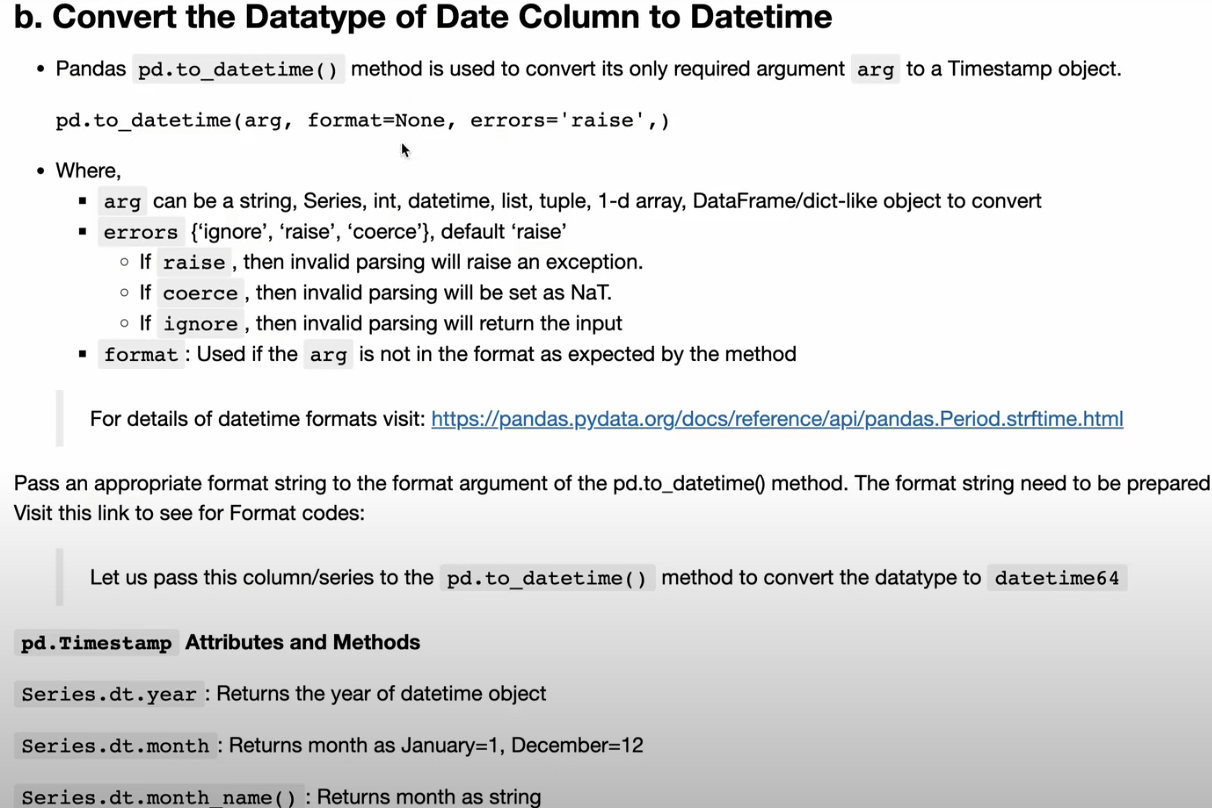

In [66]:
pd.to_datetime('06-03-2024')

Timestamp('2024-06-03 00:00:00')

In [67]:
pd.to_datetime('06-03-2024').month

6

In [68]:
d = pd.to_datetime('06-03-2024', format='%d-%m-%Y')

In [69]:
d.day, d.month, d.year

(6, 3, 2024)

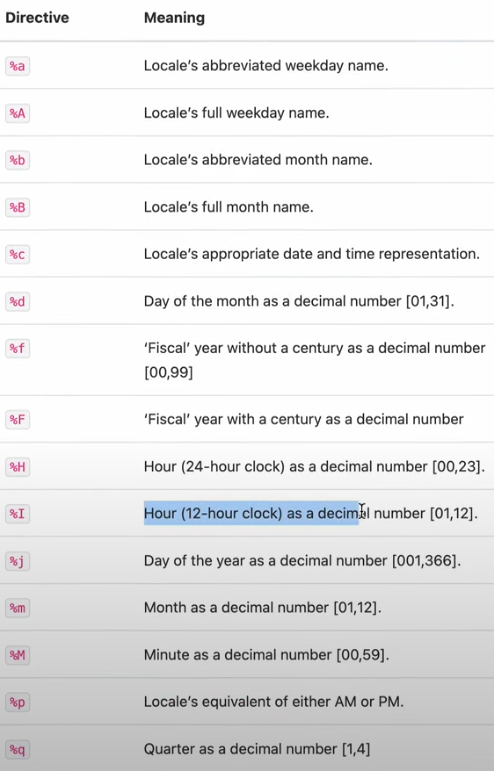

In [70]:
d = pd.to_datetime('06-03-2024 08-PM', format='%d-%m-%Y %I-%p')
df

,Date,Symbol,Open,High,Low,Close,Volume
0,2020-03-13 08-PM,ETHUSD,129.94,131.82,126.87,128.71,1940673.93
1,2020-03-13 07-PM,ETHUSD,119.51,132.02,117.10,129.94,7579741.09
2,a,ETHUSD,124.47,124.85,115.50,119.51,4898735.81
3,2020-03-13 05-PM,ETHUSD,124.08,127.42,121.63,124.47,2753450.92
4,2020-03-13 04-PM,ETHUSD,124.85,129.51,120.17,124.08,4461424.71
...,...,...,...,...,...,...,...
23669,2017-07-01 03-PM,ETHUSD,265.74,272.74,265.00,272.57,1500282.55
23670,2017-07-01 02-PM,ETHUSD,268.79,269.90,265.00,265.74,1702536.85
23671,2017-07-01 01-PM,ETHUSD,274.83,274.93,265.00,268.79,3010787.99
23672,2017-07-01 12-PM,ETHUSD,275.01,275.01,271.00,274.83,824362.87


In [71]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d %I-%p', errors='coerce')
df

,Date,Symbol,Open,High,Low,Close,Volume
0,2020-03-13 20:00:00,ETHUSD,129.94,131.82,126.87,128.71,1940673.93
1,2020-03-13 19:00:00,ETHUSD,119.51,132.02,117.10,129.94,7579741.09
2,NaT,ETHUSD,124.47,124.85,115.50,119.51,4898735.81
3,2020-03-13 17:00:00,ETHUSD,124.08,127.42,121.63,124.47,2753450.92
4,2020-03-13 16:00:00,ETHUSD,124.85,129.51,120.17,124.08,4461424.71
...,...,...,...,...,...,...,...
23669,2017-07-01 15:00:00,ETHUSD,265.74,272.74,265.00,272.57,1500282.55
23670,2017-07-01 14:00:00,ETHUSD,268.79,269.90,265.00,265.74,1702536.85
23671,2017-07-01 13:00:00,ETHUSD,274.83,274.93,265.00,268.79,3010787.99
23672,2017-07-01 12:00:00,ETHUSD,275.01,275.01,271.00,274.83,824362.87


In [72]:
df.dtypes

Date      datetime64[ns]
Symbol            object
Open             float64
High             float64
Low              float64
Close            float64
Volume           float64
dtype: object

In [73]:
df['Date'][0].year, df['Date'][1].day, df['Date'][0].month

(2020, 13, 3)

In [74]:
df['Date'][0]

Timestamp('2020-03-13 20:00:00')

In [75]:
df['Date'][0].day_name(),df['Date'][0].day,df['Date'][0].month_name(),df['Date'][0].year

('Friday', 13, 'March', 2020)

In [76]:
df['Date'].dt.day_name()

0          Friday
1          Friday
2             NaN
3          Friday
4          Friday
           ...   
23669    Saturday
23670    Saturday
23671    Saturday
23672    Saturday
23673    Saturday
Name: Date, Length: 23674, dtype: object

In [77]:
df['Date'].dt.year

0        2020.0
1        2020.0
2           NaN
3        2020.0
4        2020.0
          ...  
23669    2017.0
23670    2017.0
23671    2017.0
23672    2017.0
23673    2017.0
Name: Date, Length: 23674, dtype: float64

In [78]:
df["DayOfWeek"] = df['Date'].dt.day_name()
df

,Date,Symbol,Open,High,Low,Close,Volume,DayOfWeek
0,2020-03-13 20:00:00,ETHUSD,129.94,131.82,126.87,128.71,1940673.93,Friday
1,2020-03-13 19:00:00,ETHUSD,119.51,132.02,117.10,129.94,7579741.09,Friday
2,NaT,ETHUSD,124.47,124.85,115.50,119.51,4898735.81,NaN
3,2020-03-13 17:00:00,ETHUSD,124.08,127.42,121.63,124.47,2753450.92,Friday
4,2020-03-13 16:00:00,ETHUSD,124.85,129.51,120.17,124.08,4461424.71,Friday
...,...,...,...,...,...,...,...,...
23669,2017-07-01 15:00:00,ETHUSD,265.74,272.74,265.00,272.57,1500282.55,Saturday
23670,2017-07-01 14:00:00,ETHUSD,268.79,269.90,265.00,265.74,1702536.85,Saturday
23671,2017-07-01 13:00:00,ETHUSD,274.83,274.93,265.00,268.79,3010787.99,Saturday
23672,2017-07-01 12:00:00,ETHUSD,275.01,275.01,271.00,274.83,824362.87,Saturday


In [79]:
df["year"] = df['Date'].dt.year

df["month"] = df['Date'].dt.month

df["day"] = df['Date'].dt.day

df['month_name'] = df['Date'].dt.month_name()

df["day_name"] = df['Date'].dt.day_name()

df['date_is_weeked'] = np.where(df['day_name'].isin( ['Saturday', 'Sunday']), 1, 0 )

df.head()

,Date,Symbol,Open,High,Low,Close,Volume,DayOfWeek,year,month,day,month_name,day_name,date_is_weeked
0,2020-03-13 20:00:00,ETHUSD,129.94,131.82,126.87,128.71,1940673.93,Friday,2020.0,3.0,13.0,March,Friday,0
1,2020-03-13 19:00:00,ETHUSD,119.51,132.02,117.10,129.94,7579741.09,Friday,2020.0,3.0,13.0,March,Friday,0
2,NaT,ETHUSD,124.47,124.85,115.50,119.51,4898735.81,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2020-03-13 17:00:00,ETHUSD,124.08,127.42,121.63,124.47,2753450.92,Friday,2020.0,3.0,13.0,March,Friday,0
4,2020-03-13 16:00:00,ETHUSD,124.85,129.51,120.17,124.08,4461424.71,Friday,2020.0,3.0,13.0,March,Friday,0


In [80]:
df['Date'].min(), df['Date'].max()

(Timestamp('2017-07-01 11:00:00'), Timestamp('2020-03-13 20:00:00'))

In [81]:
df['Date'].max() - df['Date'].min()

Timedelta('986 days 09:00:00')

In [82]:
import numpy as np
import pandas as pd
from sklearn import datasets

titanic = datasets.fetch_openml(name='titanic', version=1)
df = pd.DataFrame(titanic.data, columns=titanic.feature_names)
df['target'] = titanic.target
df.head(3)

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,target
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0


## **Droping Unneccessary Column:**

In [83]:
print(df.columns.tolist())


['pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest', 'target']


In [84]:
df.drop(columns=['name', 'pclass', 'ticket', 'fare', 'embarked', 'boat', 'body', 'home.dest', 'target'], inplace=True)

df

,sex,age,sibsp,parch,cabin
0,female,29.0000,0,0,B5
1,male,0.9167,1,2,C22 C26
2,female,2.0000,1,2,C22 C26
3,male,30.0000,1,2,C22 C26
4,female,25.0000,1,2,C22 C26
...,...,...,...,...,...
1304,female,14.5000,1,0,NaN
1305,female,NaN,1,0,NaN
1306,male,26.5000,0,0,NaN
1307,male,27.0000,0,0,NaN


In [87]:
df['travel_alone'] = np.where((df['sibsp']+df['parch']) > 0, 1, 0 )
df.drop(columns=['sibsp', 'parch'], inplace=True)
df.head(3)

,sex,age,cabin,travel_alone
0,female,29.0000,B5,0
1,male,0.9167,C22 C26,1
2,female,2.0000,C22 C26,1
